### Load MITgcm Output from Assimilations

In [1]:
foldername = '/home/edavenport/analysis/vel-assim-manuscript/assimilation_results/'

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
from xmitgcm import open_mdsdataset
import numpy as np
import xarray as xr

prefix = ['diag_state']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

data_dir = '/data/SO3/edavenport/tpose6/sep2012/run_iter24/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YC.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


### Load TAO U and V

In [4]:
lon_str = '140'
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_140 = xr.open_dataset(TAO_ADCP_file)

lon_str = '110'
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_110 = xr.open_dataset(TAO_ADCP_file)

lon_str = '170'
TAO_ADCP_file = '/data/SO3/edavenport/TAO_2012to2016_daily/ADCP_2012to2016_0N' + lon_str + 'W_daily.cdf' 
dsTAO_170 = xr.open_dataset(TAO_ADCP_file)

dsTAO = xr.merge([dsTAO_110,dsTAO_140,dsTAO_170])
dsTAO['depth'] = -1*dsTAO.depth
dsTAO = dsTAO.sel(time=slice('2012-09-01','2013-06-30')) # subset to sep 2012, june 2013
dsTAO['u_1205'] = dsTAO.u_1205/100 # convert from cm/s to m/s
dsTAO['v_1206'] = dsTAO.v_1206/100 # convert from cm/s to m/s

# The shallowest bins (-10 to -20 m) are entirely NaN for this period.
# Shallower bins like -25 m and -30 m have partial coverage, but their means
# are concurrent with the model means because interp_like propagates TAO NaNs
# into the TPOSE arrays. Both datasets are averaged over the same time steps
# at each depth, so the comparison is valid and the shallow bins should be kept.
# See outliers/adcp_verification.ipynb for details.

/tmp/ipykernel_324041/3586744361.py:13: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  dsTAO = xr.merge([dsTAO_110,dsTAO_140,dsTAO_170])
/tmp/ipykernel_324041/3586744361.py:13: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  dsTAO = xr.merge([dsTAO_110,dsTAO_140,dsTAO_170])
/tmp/ipykernel_324041/3586744361.py:13: FutureWarning: In a future version of xarray t

In [5]:
dsTAO

<xarray.Dataset> Size: 904kB
Dimensions:  (time: 303, depth: 62, lat: 1, lon: 3)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2012-09-01T12:00:00 ... 2013-06-30T12:...
  * depth    (depth) float32 248B -10.0 -15.0 -20.0 ... -305.0 -310.0 -315.0
  * lat      (lat) float32 4B 0.0
  * lon      (lon) float32 12B 190.0 220.0 250.0
Data variables:
    u_1205   (time, depth, lat, lon) float32 225kB nan nan nan ... nan nan nan
    QU_5205  (time, depth, lat, lon) float32 225kB 0.0 0.0 0.0 ... 0.0 nan 0.0
    v_1206   (time, depth, lat, lon) float32 225kB nan nan nan ... nan nan nan
    QV_5206  (time, depth, lat, lon) float32 225kB 0.0 0.0 0.0 ... 0.0 nan 0.0
Attributes:
    platform_code:                0n110w
    site_code:                    0n110w
    wmo_platform_code:            32323
    array:                        TAO/TRITON
    Request_for_acknowledgement:  If you use these data in publications or pr...
    Data_Source:                  Global Tropical Moored Buoy Array Project O...
    File_info:                    Contact: Dai.C.McClurg@noaa.gov
    missing_value:                1e+35
    _FillValue:                   1e+35
    CREATION_DATE:                09:59 14-AUG-2024

In [6]:
# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'depth':'Z','lat':'YC','lon':'XG'})
tpose_U_noTAO = ds_tpose_noTAO.UVEL.interp_like(dsTAO.u_1205).compute().squeeze()
tpose_U_TAO = ds_tpose_TAO.UVEL.interp_like(dsTAO.u_1205).compute().squeeze()

# Propagate TAO NaNs into model so means are computed over the same time steps.
# Squeeze the mask to match the already-squeezed TPOSE arrays (removes singleton YC).
u_tao_mask = ~np.isnan(dsTAO.u_1205.squeeze())
tpose_U_noTAO = tpose_U_noTAO.where(u_tao_mask)
tpose_U_TAO   = tpose_U_TAO.where(u_tao_mask)

# rename TAO coords/dims so that depth is Z, lat is YC, lon is XC
dsTAO = dsTAO.rename({'XG':'XC','YC':'YG'})
tpose_V_noTAO = ds_tpose_noTAO.VVEL.interp_like(dsTAO.v_1206).compute().squeeze()
tpose_V_TAO = ds_tpose_TAO.VVEL.interp_like(dsTAO.v_1206).compute().squeeze()

# Propagate TAO NaNs into model so means are computed over the same time steps.
v_tao_mask = ~np.isnan(dsTAO.v_1206.squeeze())
tpose_V_noTAO = tpose_V_noTAO.where(v_tao_mask)
tpose_V_TAO   = tpose_V_TAO.where(v_tao_mask)

In [7]:
def vertical_shear(U):
    # dU/dz on Z grid (units: s^-1)
    return U.differentiate('Z')

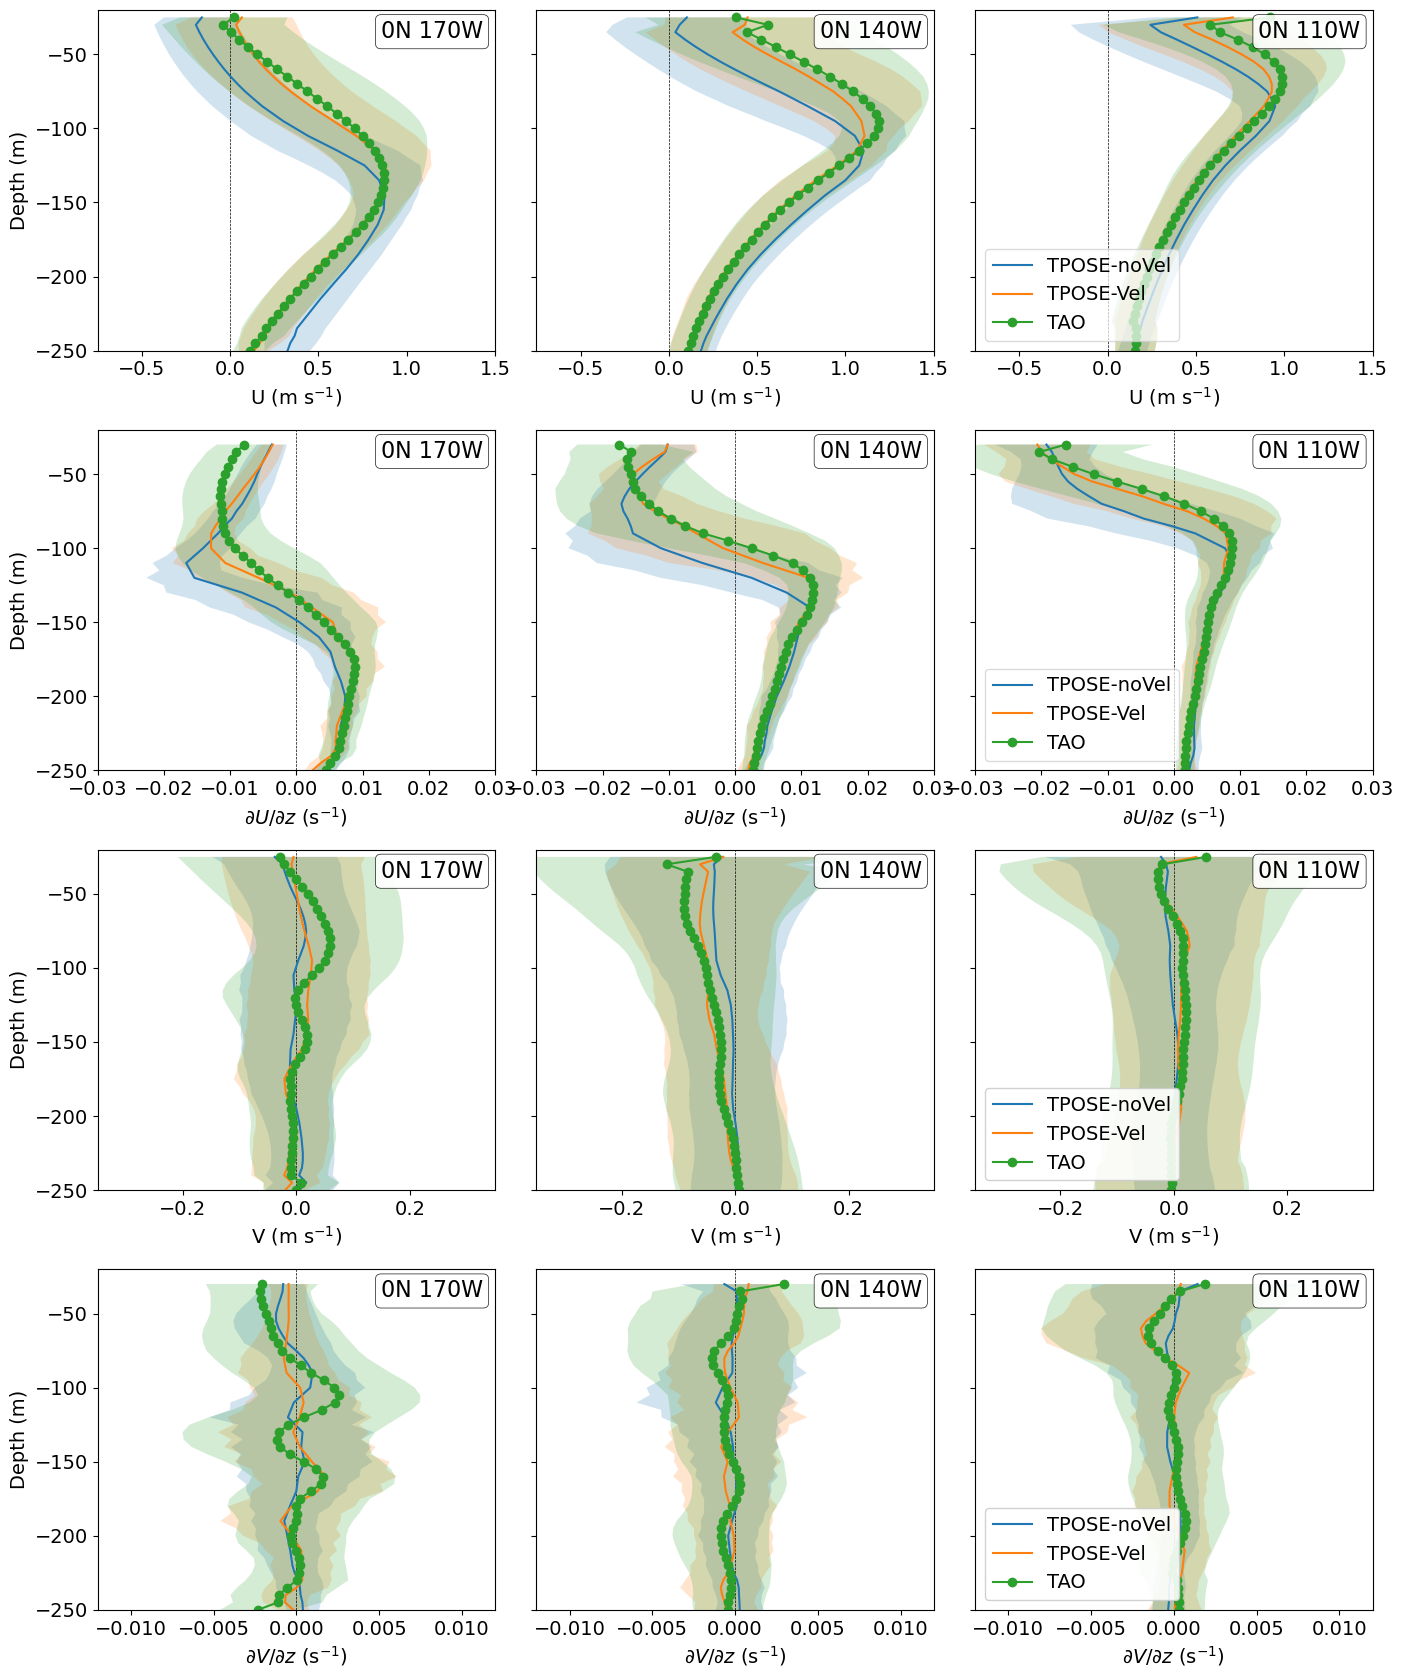

In [ ]:
plt.rcParams['font.size'] = 14
fig, ax = plt.subplots(
    figsize=(14, 17),
    nrows=4,
    ncols=3,
    sharey=True
)

XGs = [190.0, 220.0, 250.0]
titles = ['0N 170W', '0N 140W', '0N 110W']

for i, (xg, title) in enumerate(zip(XGs, titles)):

    # ------------------
    # Velocity (row 0)
    # ------------------
    ax[0, i].axvline(0, color='k', lw=0.5, ls='--')

    U_noTAO = tpose_U_noTAO.sel(XG=xg)
    U_withTAO = tpose_U_TAO.sel(XG=xg)

    U_noTAO.mean('time').plot(ax=ax[0, i], y='Z', label='TPOSE-noVel')
    ax[0, i].fill_betweenx(
        U_noTAO.Z,
        U_noTAO.mean('time') - U_noTAO.std('time'),
        U_noTAO.mean('time') + U_noTAO.std('time'),
        alpha=0.2
    )

    U_withTAO.mean('time').plot(ax=ax[0, i], y='Z', label='TPOSE-Vel')
    ax[0, i].fill_betweenx(
        U_withTAO.Z,
        U_withTAO.mean('time') - U_withTAO.std('time'),
        U_withTAO.mean('time') + U_withTAO.std('time'),
        alpha=0.2
    )

    TAO_mean = dsTAO.u_1205.sel(XC=xg).mean('time').squeeze()
    TAO_std  = dsTAO.u_1205.sel(XC=xg).std('time').squeeze()

    TAO_mean.plot(ax=ax[0, i], y='Z', marker='o', label='TAO')
    ax[0, i].fill_betweenx(
        dsTAO.Z, TAO_mean - TAO_std, TAO_mean + TAO_std,
        alpha=0.2
    )

    ax[0, i].set_title('')
    ax[0, i].set_ylim(-250, -20)
    ax[0, i].set_xlim(-0.75, 1.5)
    ax[0, i].set_xlabel('U (m s$^{-1}$)')
    ax[0, i].set_ylabel('')

    # ------------------
    # Shear (row 1)
    # ------------------
    ax[1, i].axvline(0, color='k', lw=0.5, ls='--')

    dUdz_noTAO   = vertical_shear(U_noTAO)
    dUdz_withTAO = vertical_shear(U_withTAO)
    dUdz_TAO     = vertical_shear(dsTAO.u_1205.sel(XC=xg))

    # Means
    m_noTAO   = dUdz_noTAO.mean('time')
    m_withTAO = dUdz_withTAO.mean('time')
    m_TAO     = dUdz_TAO.mean('time').squeeze()

    # STDs
    s_noTAO   = dUdz_noTAO.std('time')
    s_withTAO = dUdz_withTAO.std('time')
    s_TAO     = dUdz_TAO.std('time').squeeze()

    # Plot means
    m_noTAO.plot(ax=ax[1, i], y='Z', label='TPOSE-noVel')
    m_withTAO.plot(ax=ax[1, i], y='Z', label='TPOSE-Vel')
    m_TAO.plot(ax=ax[1, i], y='Z', marker='o', label='TAO')

    # Shading
    ax[1, i].fill_betweenx(
        m_noTAO.Z,
        m_noTAO - s_noTAO,
        m_noTAO + s_noTAO,
        alpha=0.2
    )

    ax[1, i].fill_betweenx(
        m_withTAO.Z,
        m_withTAO - s_withTAO,
        m_withTAO + s_withTAO,
        alpha=0.2
    )

    ax[1, i].fill_betweenx(
        dsTAO.Z,
        m_TAO - s_TAO,
        m_TAO + s_TAO,
        alpha=0.2
    )

    ax[1, i].set_title('')
    ax[1, i].set_ylim(-250, -20)
    ax[1, i].set_xlim(-0.03, 0.03)
    ax[1, i].set_xlabel(r'$\partial U / \partial z$ (s$^{-1}$)')
    ax[1, i].set_ylabel('')

    # Set title in upper right corner of each subplot
    for r in [0, 1]:
        ax[r, i].text(
            0.97, 0.97, title,
            transform=ax[r, i].transAxes,
            ha='right', va='top',
            fontsize=16,
            bbox=dict(
                boxstyle='round,pad=0.25',
                facecolor='white',
                edgecolor='k',
                linewidth=0.5,
                alpha=0.9
            )
        )


ax[0, 0].set_ylabel('Depth (m)')
ax[1, 0].set_ylabel('Depth (m)')

ax[0, 2].legend(loc='lower left', framealpha=0.7)
ax[1, 2].legend(loc='lower left', framealpha=0.7)

for i, (xg, title) in enumerate(zip(XGs, titles)):

    # ------------------
    # Velocity (row 2)
    # ------------------
    ax[2, i].axvline(0, color='k', lw=0.5, ls='--')

    V_noTAO = tpose_V_noTAO.sel(XC=xg)
    V_withTAO = tpose_V_TAO.sel(XC=xg)

    V_noTAO.mean('time').plot(ax=ax[2, i], y='Z', label='TPOSE-noVel')
    ax[2, i].fill_betweenx(
        V_noTAO.Z,
        V_noTAO.mean('time') - V_noTAO.std('time'),
        V_noTAO.mean('time') + V_noTAO.std('time'),
        alpha=0.2
    )

    V_withTAO.mean('time').plot(ax=ax[2, i], y='Z', label='TPOSE-Vel')
    ax[2, i].fill_betweenx(
        V_withTAO.Z,
        V_withTAO.mean('time') - V_withTAO.std('time'),
        V_withTAO.mean('time') + V_withTAO.std('time'),
        alpha=0.2
    )

    TAO_mean = dsTAO.v_1206.sel(XC=xg).mean('time').squeeze()
    TAO_std  = dsTAO.v_1206.sel(XC=xg).std('time').squeeze()

    TAO_mean.plot(ax=ax[2, i], y='Z', marker='o', label='TAO')
    ax[2, i].fill_betweenx(
        dsTAO.Z, TAO_mean - TAO_std, TAO_mean + TAO_std,
        alpha=0.2
    )

    ax[2, i].set_title('')
    ax[2, i].set_ylim(-250, -20)
    ax[2, i].set_xlim(-0.35, 0.35)
    ax[2, i].set_xlabel('V (m s$^{-1}$)')
    ax[2, i].set_ylabel('')

    # ------------------
    # Shear (row 3)
    # ------------------
    ax[3, i].axvline(0, color='k', lw=0.5, ls='--')

    dVdz_noTAO   = vertical_shear(V_noTAO)
    dVdz_withTAO = vertical_shear(V_withTAO)
    dVdz_TAO     = vertical_shear(dsTAO.v_1206.sel(XC=xg))

    # Means
    m_noTAO   = dVdz_noTAO.mean('time')
    m_withTAO = dVdz_withTAO.mean('time')
    m_TAO     = dVdz_TAO.mean('time').squeeze()

    # STDs
    s_noTAO   = dVdz_noTAO.std('time')
    s_withTAO = dVdz_withTAO.std('time')
    s_TAO     = dVdz_TAO.std('time').squeeze()

    # Plot means
    m_noTAO.plot(ax=ax[3, i], y='Z', label='TPOSE-noVel')
    m_withTAO.plot(ax=ax[3, i], y='Z', label='TPOSE-Vel')
    m_TAO.plot(ax=ax[3, i], y='Z', marker='o', label='TAO')

    # Shading
    ax[3, i].fill_betweenx(
        m_noTAO.Z,
        m_noTAO - s_noTAO,
        m_noTAO + s_noTAO,
        alpha=0.2
    )

    ax[3, i].fill_betweenx(
        m_withTAO.Z,
        m_withTAO - s_withTAO,
        m_withTAO + s_withTAO,
        alpha=0.2
    )

    ax[3, i].fill_betweenx(
        dsTAO.Z,
        m_TAO - s_TAO,
        m_TAO + s_TAO,
        alpha=0.2
    )

    ax[3, i].set_title('')
    ax[3, i].set_ylim(-250, -20)
    ax[3, i].set_xlim(-0.012, 0.012)
    ax[3, i].set_xlabel(r'$\partial V / \partial z$ (s$^{-1}$)')
    ax[3, i].set_ylabel('')

    # Set title in upper right corner of each subplot
    for r in [2, 3]:
        ax[r, i].text(
            0.97, 0.97, title,
            transform=ax[r, i].transAxes,
            ha='right', va='top',
            fontsize=16,
            bbox=dict(
                boxstyle='round,pad=0.25',
                facecolor='white',
                edgecolor='k',
                linewidth=0.5,
                alpha=0.9
            )
        )


ax[2, 0].set_ylabel('Depth (m)')
ax[3, 0].set_ylabel('Depth (m)')

ax[2, 2].legend(loc='lower left', framealpha=0.9)
ax[3, 2].legend(loc='lower left', framealpha=0.9)

plt.tight_layout()
fig.savefig(foldername + 'shear_mean_prof.png')

In [9]:
xg = 190
V_noTAO = tpose_V_noTAO.sel(XC=xg)
V_withTAO = tpose_V_TAO.sel(XC=xg)
U_noTAO = tpose_U_noTAO.sel(XG=xg)
U_withTAO = tpose_U_TAO.sel(XG=xg)

dVdz_noTAO   = vertical_shear(V_noTAO)
dVdz_withTAO = vertical_shear(V_withTAO)
dVdz_TAO     = vertical_shear(dsTAO.v_1206.sel(XC=xg))

dUdz_noTAO   = vertical_shear(U_noTAO)
dUdz_withTAO = vertical_shear(U_withTAO)
dUdz_TAO     = vertical_shear(dsTAO.u_1205.sel(XC=xg))

rmsd_v = np.sqrt(((dVdz_withTAO-dVdz_TAO)**2).mean())
rmsd_u = np.sqrt(((dUdz_withTAO-dUdz_TAO)**2).mean())
rmsd_v_noTAO = np.sqrt(((dVdz_noTAO-dVdz_TAO)**2).mean())
rmsd_u_noTAO = np.sqrt(((dUdz_noTAO-dUdz_TAO)**2).mean())

print(f'170W, RMSD of dV/dz with TAO: {rmsd_v:.6f} s^-1')
print(f'170W, RMSD of dU/dz with TAO: {rmsd_u:.6f} s^-1')
print(f'170W, RMSD of dV/dz no TAO: {rmsd_v_noTAO:.6f} s^-1')
print(f'170W, RMSD of dU/dz no TAO: {rmsd_u_noTAO:.6f} s^-1')

print(f'170W, % change V RMSD={100*(rmsd_v - rmsd_v_noTAO)/rmsd_v_noTAO:.1f}%')
print(f'170W, % change U RMSD={100*(rmsd_u - rmsd_u_noTAO)/rmsd_u_noTAO:.1f}%')

170W, RMSD of dV/dz with TAO: 0.004339 s^-1
170W, RMSD of dU/dz with TAO: 0.005692 s^-1
170W, RMSD of dV/dz no TAO: 0.004796 s^-1
170W, RMSD of dU/dz no TAO: 0.007923 s^-1
170W, % change V RMSD=-9.5%
170W, % change U RMSD=-28.2%


In [10]:
xg = 220
V_noTAO = tpose_V_noTAO.sel(XC=xg)
V_withTAO = tpose_V_TAO.sel(XC=xg)

dVdz_noTAO   = vertical_shear(V_noTAO)
dVdz_withTAO = vertical_shear(V_withTAO)
dVdz_TAO     = vertical_shear(dsTAO.v_1206.sel(XC=xg))

dUdz_noTAO   = vertical_shear(U_noTAO)
dUdz_withTAO = vertical_shear(U_withTAO)
dUdz_TAO     = vertical_shear(dsTAO.u_1205.sel(XC=xg))

rmsd_v = np.sqrt(((dVdz_withTAO-dVdz_TAO)**2).mean())
rmsd_u = np.sqrt(((dUdz_withTAO-dUdz_TAO)**2).mean())
rmsd_v_noTAO = np.sqrt(((dVdz_noTAO-dVdz_TAO)**2).mean())
rmsd_u_noTAO = np.sqrt(((dUdz_noTAO-dUdz_TAO)**2).mean())

print(f'140W, RMSD of dV/dz with TAO: {rmsd_v:.6f} s^-1')
print(f'140W, RMSD of dU/dz with TAO: {rmsd_u:.6f} s^-1')
print(f'140W, RMSD of dV/dz no TAO: {rmsd_v_noTAO:.6f} s^-1')
print(f'140W, RMSD of dU/dz no TAO: {rmsd_u_noTAO:.6f} s^-1')

print(f'140W, % change V RMSD={100*(rmsd_v - rmsd_v_noTAO)/rmsd_v_noTAO:.1f}%')
print(f'140W, % change U RMSD={100*(rmsd_u - rmsd_u_noTAO)/rmsd_u_noTAO:.1f}%')

140W, RMSD of dV/dz with TAO: 0.003711 s^-1
140W, RMSD of dU/dz with TAO: 0.012874 s^-1
140W, RMSD of dV/dz no TAO: 0.004203 s^-1
140W, RMSD of dU/dz no TAO: 0.015251 s^-1
140W, % change V RMSD=-11.7%
140W, % change U RMSD=-15.6%


In [11]:
xg = 250
V_noTAO = tpose_V_noTAO.sel(XC=xg)
V_withTAO = tpose_V_TAO.sel(XC=xg)

dVdz_noTAO   = vertical_shear(V_noTAO)
dVdz_withTAO = vertical_shear(V_withTAO)
dVdz_TAO     = vertical_shear(dsTAO.v_1206.sel(XC=xg))

dUdz_noTAO   = vertical_shear(U_noTAO)
dUdz_withTAO = vertical_shear(U_withTAO)
dUdz_TAO     = vertical_shear(dsTAO.u_1205.sel(XC=xg))

rmsd_v = np.sqrt(((dVdz_withTAO-dVdz_TAO)**2).mean())
rmsd_u = np.sqrt(((dUdz_withTAO-dUdz_TAO)**2).mean())
rmsd_v_noTAO = np.sqrt(((dVdz_noTAO-dVdz_TAO)**2).mean())
rmsd_u_noTAO = np.sqrt(((dUdz_noTAO-dUdz_TAO)**2).mean())

print(f'110W, RMSD of dV/dz with TAO: {rmsd_v:.6f} s^-1')
print(f'110W, RMSD of dU/dz with TAO: {rmsd_u:.6f} s^-1')
print(f'110W, RMSD of dV/dz no TAO: {rmsd_v_noTAO:.6f} s^-1')
print(f'110W, RMSD of dU/dz no TAO: {rmsd_u_noTAO:.6f} s^-1')

print(f'110W, % change V RMSD={100*(rmsd_v - rmsd_v_noTAO)/rmsd_v_noTAO:.1f}%')
print(f'110W, % change U RMSD={100*(rmsd_u - rmsd_u_noTAO)/rmsd_u_noTAO:.1f}%')

110W, RMSD of dV/dz with TAO: 0.003734 s^-1
110W, RMSD of dU/dz with TAO: 0.014054 s^-1
110W, RMSD of dV/dz no TAO: 0.004459 s^-1
110W, RMSD of dU/dz no TAO: 0.015438 s^-1
110W, % change V RMSD=-16.3%
110W, % change U RMSD=-9.0%
